In [1]:
import pandas as pd

df = pd.read_csv("ai-adoption-fortune500-synthetic-dataset-2020-2025.csv")

# Convert Year to datetime index
df['Year'] = pd.to_datetime(df['Year'], format='%Y')
df.set_index('Year', inplace=True)

print(df[['Company','Revenue_USD']].head())

           Company   Revenue_USD
Year                            
2020-01-01  Amazon  4.535464e+11
2021-01-01  Amazon  4.878035e+11
2022-01-01  Amazon  2.182500e+11
2023-01-01  Amazon  4.114132e+11
2024-01-01  Amazon  3.191970e+11


In [2]:
df['AI_ROI_Percent'] = df['AI_ROI_Percent'].interpolate()

print(df['AI_ROI_Percent'].head())

Year
2020-01-01    30.33
2021-01-01    19.09
2022-01-01    34.99
2023-01-01    23.96
2024-01-01     0.00
Name: AI_ROI_Percent, dtype: float64


In [3]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Revenue_USD'])

print("ADF p-value:", result[1])

ADF p-value: 2.985523307138331e-14


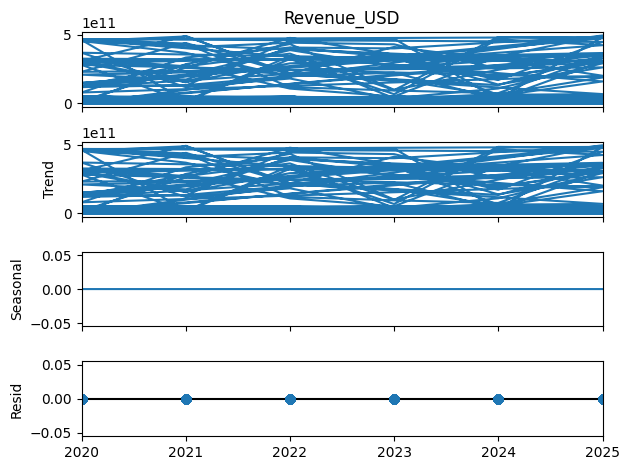

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomp = seasonal_decompose(df['Revenue_USD'], model='additive', period=1)

decomp.plot()
plt.show()

In [5]:
print(decomp.resid.head())

Year
2020-01-01    0.0
2021-01-01    0.0
2022-01-01    0.0
2023-01-01    0.0
2024-01-01    0.0
Name: resid, dtype: float64
